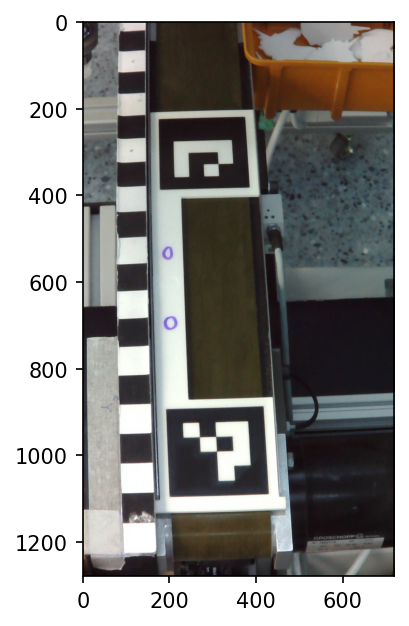

In [2]:
import cv2 as cv
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from cv2 import aruco
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150

aruco_dict = aruco.getPredefinedDictionary(aruco.DICT_4X4_100)
parameters = aruco.DetectorParameters()
detector = aruco.ArucoDetector(aruco_dict, parameters)

img_aruco = cv.imread('aruco_pic/foto_0.png')
img_aruco_rotated = cv.rotate(img_aruco,2)

# Test Bild
img_obj = cv.imread('obj/cat/foto_10.png')
img_obj_rotated = cv.rotate(img_obj,2)

SRC_COORDS = (np.array([[[ 0.,  0.],  [60., 0.],   [60., 60.],  [ 0.,60.], 
                                [ 0., 222.], [60., 222.], [60., 282.], [ 0., 282.]]], dtype= np.float32))

plt.imshow(img_aruco_rotated)

# Bildauschnitt errechnen und segmentierung einstellen

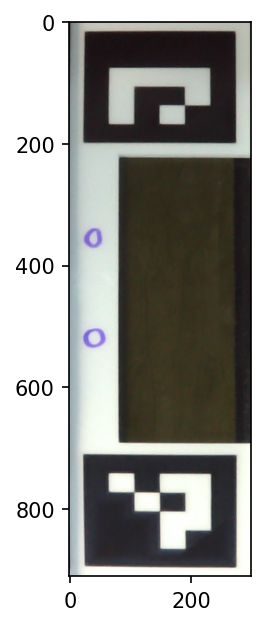

In [3]:
corners, ids, rejected = detector.detectMarkers(img_aruco_rotated)

dstPoints = np.concatenate(corners, axis=1)
H, _ = cv.findHomography(srcPoints=SRC_COORDS, dstPoints=dstPoints, method=0)
H_inv = np.linalg.inv(H)

pts1 = np.float32([
    corners[1][0][0],  # oben-links
    corners[1][0][1],  # oben-rechts
    corners[0][0][3],  # unten-links
    corners[0][0][2],  # unten-rechts
])

pts1_reshaped = pts1.astype(np.float32).reshape(-1, 1, 2)

# Pixel in Bild zu welt
world_frame = cv.perspectiveTransform(pts1_reshaped, H_inv)

# versatz - mit X und Y Offsets
offset_raw = np.array([
    [-6, +6],  # mm - X offset -6, Y offset -6
    [+6, +6],  # mm - X offset +6, Y offset -6
    [-6, -6],  # mm - X offset -6, Y offset +6
    [+6, -6]   # mm - X offset +6, Y offset +6
], dtype=np.float32)

offset = offset_raw.reshape(-1, 1, 2)
pts1_2 = world_frame + offset

pts1_2_pixel = cv.perspectiveTransform(pts1_2, H)

min_x = np.min(pts1_2_pixel[:, 0, 0])
max_x = np.max(pts1_2_pixel[:, 0, 0])
min_y = np.min(pts1_2_pixel[:, 0, 1])
max_y = np.max(pts1_2_pixel[:, 0, 1])

width = int(max_x - min_x)
height = int(max_y - min_y)

pts2_proportional = np.float32([
    [0, 0],
    [width, 0],
    [0, height],
    [width, height]
])
M_for_all = cv.getPerspectiveTransform(pts1_2_pixel, pts2_proportional)

img_warped = cv.warpPerspective(img_aruco_rotated, M_for_all, (width, height))
plt.imshow(img_warped)

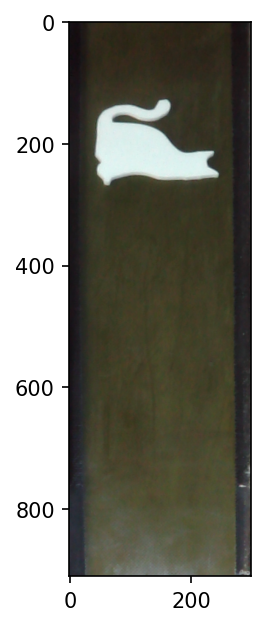

In [4]:
dst_obj = cv.warpPerspective(img_obj_rotated, M_for_all, (width, height))
plt.imshow(dst_obj)

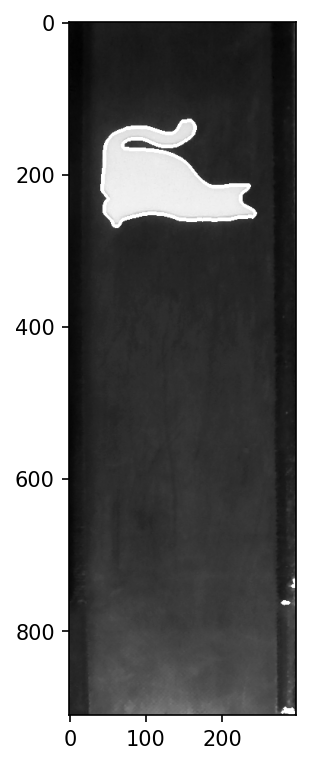

In [5]:
gray_image = cv.cvtColor(dst_obj, cv.COLOR_BGR2GRAY)

ret , img_thresh = cv.threshold(gray_image, 150, 255,cv.THRESH_BINARY)

uint8_img_thresh = img_thresh.astype(np.uint8)

contours , hierarchy = cv.findContours(uint8_img_thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)

img_with_contours = gray_image.copy()

cv.drawContours(img_with_contours, contours, contourIdx= -1 , color= (255, 255, 255),thickness=3)

plt.figure(figsize=(8, 6))
plt.imshow(img_with_contours, cmap='gray')

In [6]:
cwd = Path.cwd()

# Prefer local notebook directory if the notebook is already running from misc/prepWork/dev_pictures.
# Otherwise resolve from the repository root.
candidate_paths = [
    cwd / "obj",
    cwd / "misc" / "prepWork" / "dev_pictures" / "obj",
    cwd / "dev_pictures" / "obj",
]

for path in candidate_paths:
    if path.exists():
        DATA_PATH = path
        break
else:
    raise FileNotFoundError(
        f"DATA_PATH not found. Checked: {candidate_paths} (cwd={cwd})"
    )

print("Using DATA_PATH:", DATA_PATH)



Using DATA_PATH: /home/lbraun/Robotik/4_Semester/robotik_projekt_3/Portal-zur-Exmatrikulation/misc/prepWork/dev_pictures/obj


In [7]:
def warp_image(img):

    img_rotated = cv.rotate(img,2)

    dst_obj = cv.warpPerspective(img_rotated, M_for_all, (width, height))
    return dst_obj

def rotate_image(img, angle):
    h, w = img.shape[:2]
    center = (w // 2, h // 2)

    M = cv.getRotationMatrix2D(center, angle, 1.0)

    return cv.warpAffine(
        img,
        M,
        (w, h),
        flags=cv.INTER_LINEAR,
        borderValue=(255, 255, 255)
    )


def mirror_image(img):
    return cv.flip(img, 1)

In [8]:
def extract_main_contour(img):

    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # blur = cv.GaussianBlur(gray, (5, 5), 0)

    _, thresh = cv.threshold(gray, 150, 255, cv.THRESH_BINARY)

    uint8_img_thresh = thresh.astype(np.uint8)

    contours, _ = cv.findContours(uint8_img_thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return None

    return max(contours, key=cv.contourArea)

In [9]:
def extract_features(cnt):

    features = {}

    area = cv.contourArea(cnt)
    perimeter = cv.arcLength(cnt, True)

    if area == 0 or perimeter == 0:
        return None

    features["area"] = area
    features["perimeter"] = perimeter

    # Shape approx
    epsilon = 0.04 * perimeter
    approx = cv.approxPolyDP(cnt, epsilon, True)
    features["corners"] = len(approx)

    # Bounding box
    x, y, w, h = cv.boundingRect(cnt)

    features["aspect_ratio"] = w / h
    features["bbox_w"] = w
    features["bbox_h"] = h

    # Circularity
    features["circularity"] = (4 * np.pi * area) / (perimeter ** 2)

    # Solidity
    hull = cv.convexHull(cnt)
    hull_area = cv.contourArea(hull)

    features["solidity"] = area / hull_area if hull_area > 0 else 0

    # Hu Moments
    hu = cv.HuMoments(cv.moments(cnt)).flatten()

    for i in range(7):
        features[f"hu_{i}"] = hu[i]

    # Fourier Descriptors
    contour_pts = cnt[:, 0, :]                          # Shape: (N, 2)
    complex_contour = contour_pts[:, 0] + 1j * contour_pts[:, 1]  # Als komplexe Zahlen
    fourier = np.fft.fft(complex_contour)

    # Normalisieren: rotations-, skalierungs- und translationsinvariant
    fourier = np.abs(fourier)
    fourier /= fourier[1] if fourier[1] != 0 else 1    # Skalierungsinvarianz

    # Nur die ersten N Koeffizienten nehmen (niedrige Frequenzen = Form)
    N_DESCRIPTORS = 10
    for i in range(1, N_DESCRIPTORS + 1):
        features[f"fd_{i}"] = fourier[i] if i < len(fourier) else 0

    M_moments = cv.moments(cnt)
    features["symmetry"] = abs(M_moments["mu11"]) / (M_moments["mu20"] + M_moments["mu02"] + 1e-6)

    return features

In [10]:
angles = [0,25, 55,75, 110, 130, 165, 190, 220, 275, 300, 330]

rows = []

In [11]:
for class_dir in DATA_PATH.iterdir():

    if not class_dir.is_dir():
        continue

    label = class_dir.name
    print("Processing:", label)

    for img_path in class_dir.glob("*.png"):

        img_first = cv.imread(str(img_path))

        img = warp_image(img_first)

        if img is None:
            continue

        # Original + augmented versions
        variants = []

        # Rotations
        for angle in angles:
            variants.append(rotate_image(img, angle))

        # Mirror + rotations
        mirrored = mirror_image(img)

        for angle in angles:
            variants.append(rotate_image(mirrored, angle))

        # Feature extraction
        for v in variants:

            cnt = extract_main_contour(v)

            if cnt is None:
                continue

            feat = extract_features(cnt)

            if feat is None:
                continue

            feat["label"] = label

            rows.append(feat)

Processing: unicorn
Processing: cat


In [12]:
from pathlib import Path

DEBUG_PATH = Path("debug_contours")
DEBUG_PATH.mkdir(exist_ok=True)

for class_dir in DATA_PATH.iterdir():
    if not class_dir.is_dir():
        continue

    label = class_dir.name
    out_dir = DEBUG_PATH / label
    out_dir.mkdir(exist_ok=True)  # Unterordner pro Klasse

    for img_path in class_dir.glob("*.png"):

        img_first = cv.imread(str(img_path))

        img = warp_image(img_first)
        
        if img is None:
            continue

        cnt = extract_main_contour(img)

        if cnt is None:
            print(f"⚠️ Kein Contour gefunden: {img_path.name}")
            continue

        # Kontur auf Bild zeichnen
        debug_img = img.copy()
        cv.drawContours(debug_img, [cnt], -1, (0, 255, 0), 2)  # grüne Linie

        # Bounding Box dazu
        x, y, w, h = cv.boundingRect(cnt)
        cv.rectangle(debug_img, (x, y), (x+w, y+h), (255, 0, 0), 1)  # blaues Rechteck

        # Speichern
        out_path = out_dir / img_path.name
        cv.imwrite(str(out_path), debug_img)

print("✅ Debug-Bilder gespeichert unter:", DEBUG_PATH.resolve())

✅ Debug-Bilder gespeichert unter: /home/lbraun/Robotik/4_Semester/robotik_projekt_3/Portal-zur-Exmatrikulation/misc/prepWork/dev_pictures/debug_contours


In [13]:
df = pd.DataFrame(rows)

print("Dataset shape:", df.shape)

df.to_csv("features_dataset.csv", index=False)

df.head()

Dataset shape: (5304, 27)


,area,perimeter,corners,aspect_ratio,bbox_w,bbox_h,circularity,solidity,hu_0,hu_1,...,fd_3,fd_4,fd_5,fd_6,fd_7,fd_8,fd_9,fd_10,symmetry,label
0,16454.0,716.298551,7,1.753731,235,134,0.402989,0.755550,0.210937,0.010988,...,0.728906,0.232439,0.164599,0.301448,0.168383,0.083486,0.079992,0.067412,0.003385,unicorn
1,41131.0,1117.185853,3,0.467933,197,421,0.414122,0.994968,0.289911,0.047024,...,0.329298,0.245578,0.194898,0.161627,0.137497,0.119642,0.105815,0.094463,0.191525,unicorn
2,81051.0,1226.156412,4,0.788360,298,378,0.677449,0.998202,0.184559,0.003792,...,0.305228,0.218908,0.167255,0.132776,0.108176,0.090133,0.076400,0.065897,0.163663,unicorn
3,89285.5,1227.722870,4,0.873900,298,341,0.744372,0.998323,0.169148,0.000511,...,0.282198,0.192716,0.139350,0.103617,0.079647,0.060461,0.046378,0.036747,0.064830,unicorn
4,103274.0,1860.607206,5,0.597194,298,499,0.374879,0.816298,0.196669,0.003497,...,0.436595,0.218388,0.171675,0.194671,0.094396,0.145866,0.124190,0.072272,0.079937,unicorn


         feature    f_score       p_value
2        corners  30.213927  4.050077e-08
25      symmetry  20.548914  5.940543e-06
18          fd_4  16.363069  5.303734e-05
19          fd_5  14.547704  1.382082e-04
17          fd_3  14.409811  1.486755e-04
20          fd_6  12.838939  3.425288e-04
21          fd_7  10.496728  1.203240e-03
24         fd_10   9.051868  2.636597e-03
23          fd_9   7.225144  7.211399e-03
22          fd_8   5.087298  2.414232e-02
14          hu_6   2.675105  1.019880e-01
5         bbox_h   1.068665  3.012943e-01
1      perimeter   0.916687  3.383901e-01
16          fd_2   0.835595  3.607013e-01
0           area   0.692799  4.052516e-01
10          hu_2   0.670312  4.129798e-01
8           hu_0   0.521247  4.703419e-01
6    circularity   0.508004  4.760358e-01
7       solidity   0.279698  5.969211e-01
11          hu_3   0.175607  6.751926e-01
3   aspect_ratio   0.106427  7.442618e-01
4         bbox_w   0.099005  7.530393e-01
13          hu_5   0.071045  7.898

/home/lbraun/Robotik/4_Semester/robotik_projekt_3/Portal-zur-Exmatrikulation/.venv/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [15] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/lbraun/Robotik/4_Semester/robotik_projekt_3/Portal-zur-Exmatrikulation/.venv/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


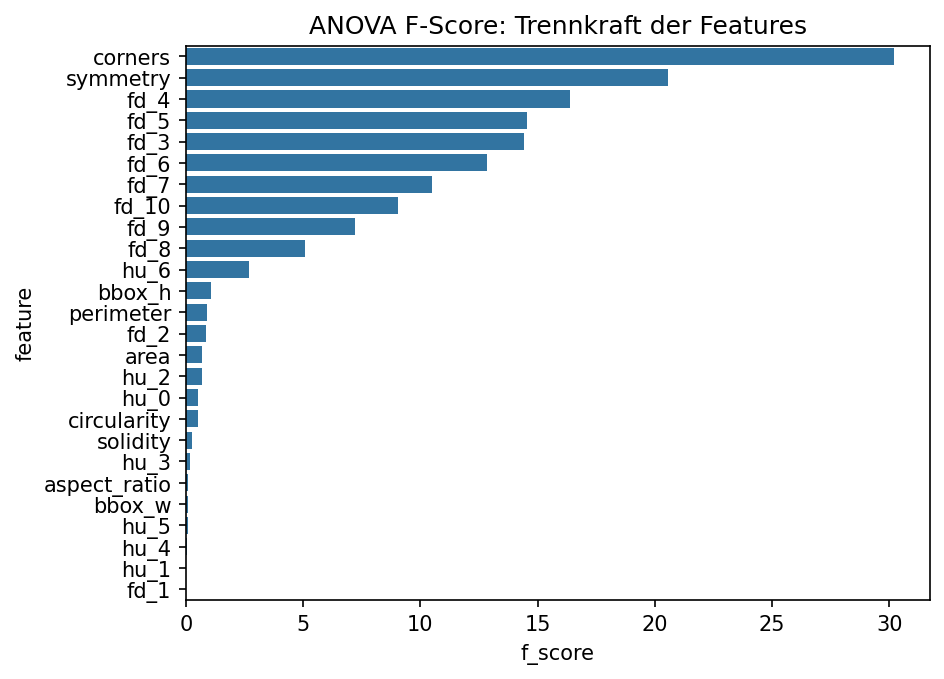

In [14]:
from sklearn.feature_selection import f_classif

X = df.drop(columns=["label"])
y = df["label"]

f_scores, p_values = f_classif(X, y)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "f_score": f_scores,
    "p_value": p_values
}).sort_values("f_score", ascending=False)

print(importance_df)

# Als Plot
sns.barplot(data=importance_df, x="f_score", y="feature")
plt.title("ANOVA F-Score: Trennkraft der Features")
plt.show()

In [15]:
selected_features_only_obj = ["corners", "fd_4","perimeter",  "circularity",    "hu_4",  "fd_2","bbox_w", "fd_1", "fd_3",  "fd_5",  "fd_7",  "fd_6", "hu_1","hu_0", "hu_2", "hu_3","hu_5","hu_6","solidity", "area" ]

selected_features = [  "corners", "symmetry", "fd_4"]

#  

X = df[selected_features]  # use the selected feature columns
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


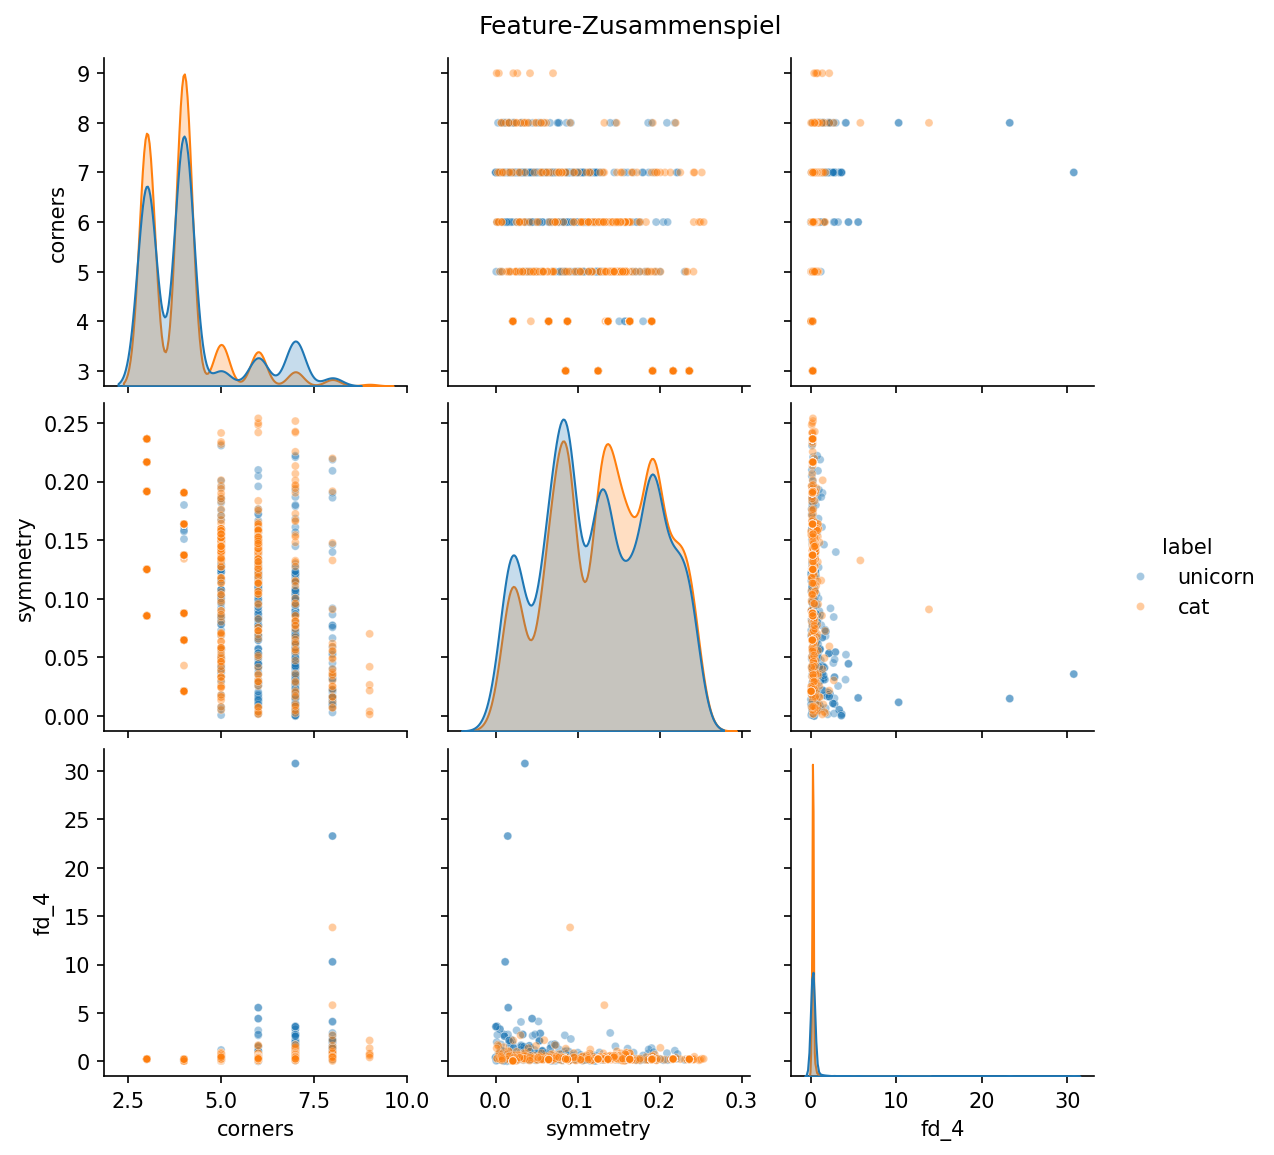

In [16]:
sns.pairplot(
    df[selected_features + ["label"]], 
    hue="label",
    plot_kws={"alpha": 0.4, "s": 15},
    diag_kind="kde"  # Verteilung auf der Diagonale
)
plt.suptitle("Feature-Zusammenspiel", y=1.02)
plt.show()

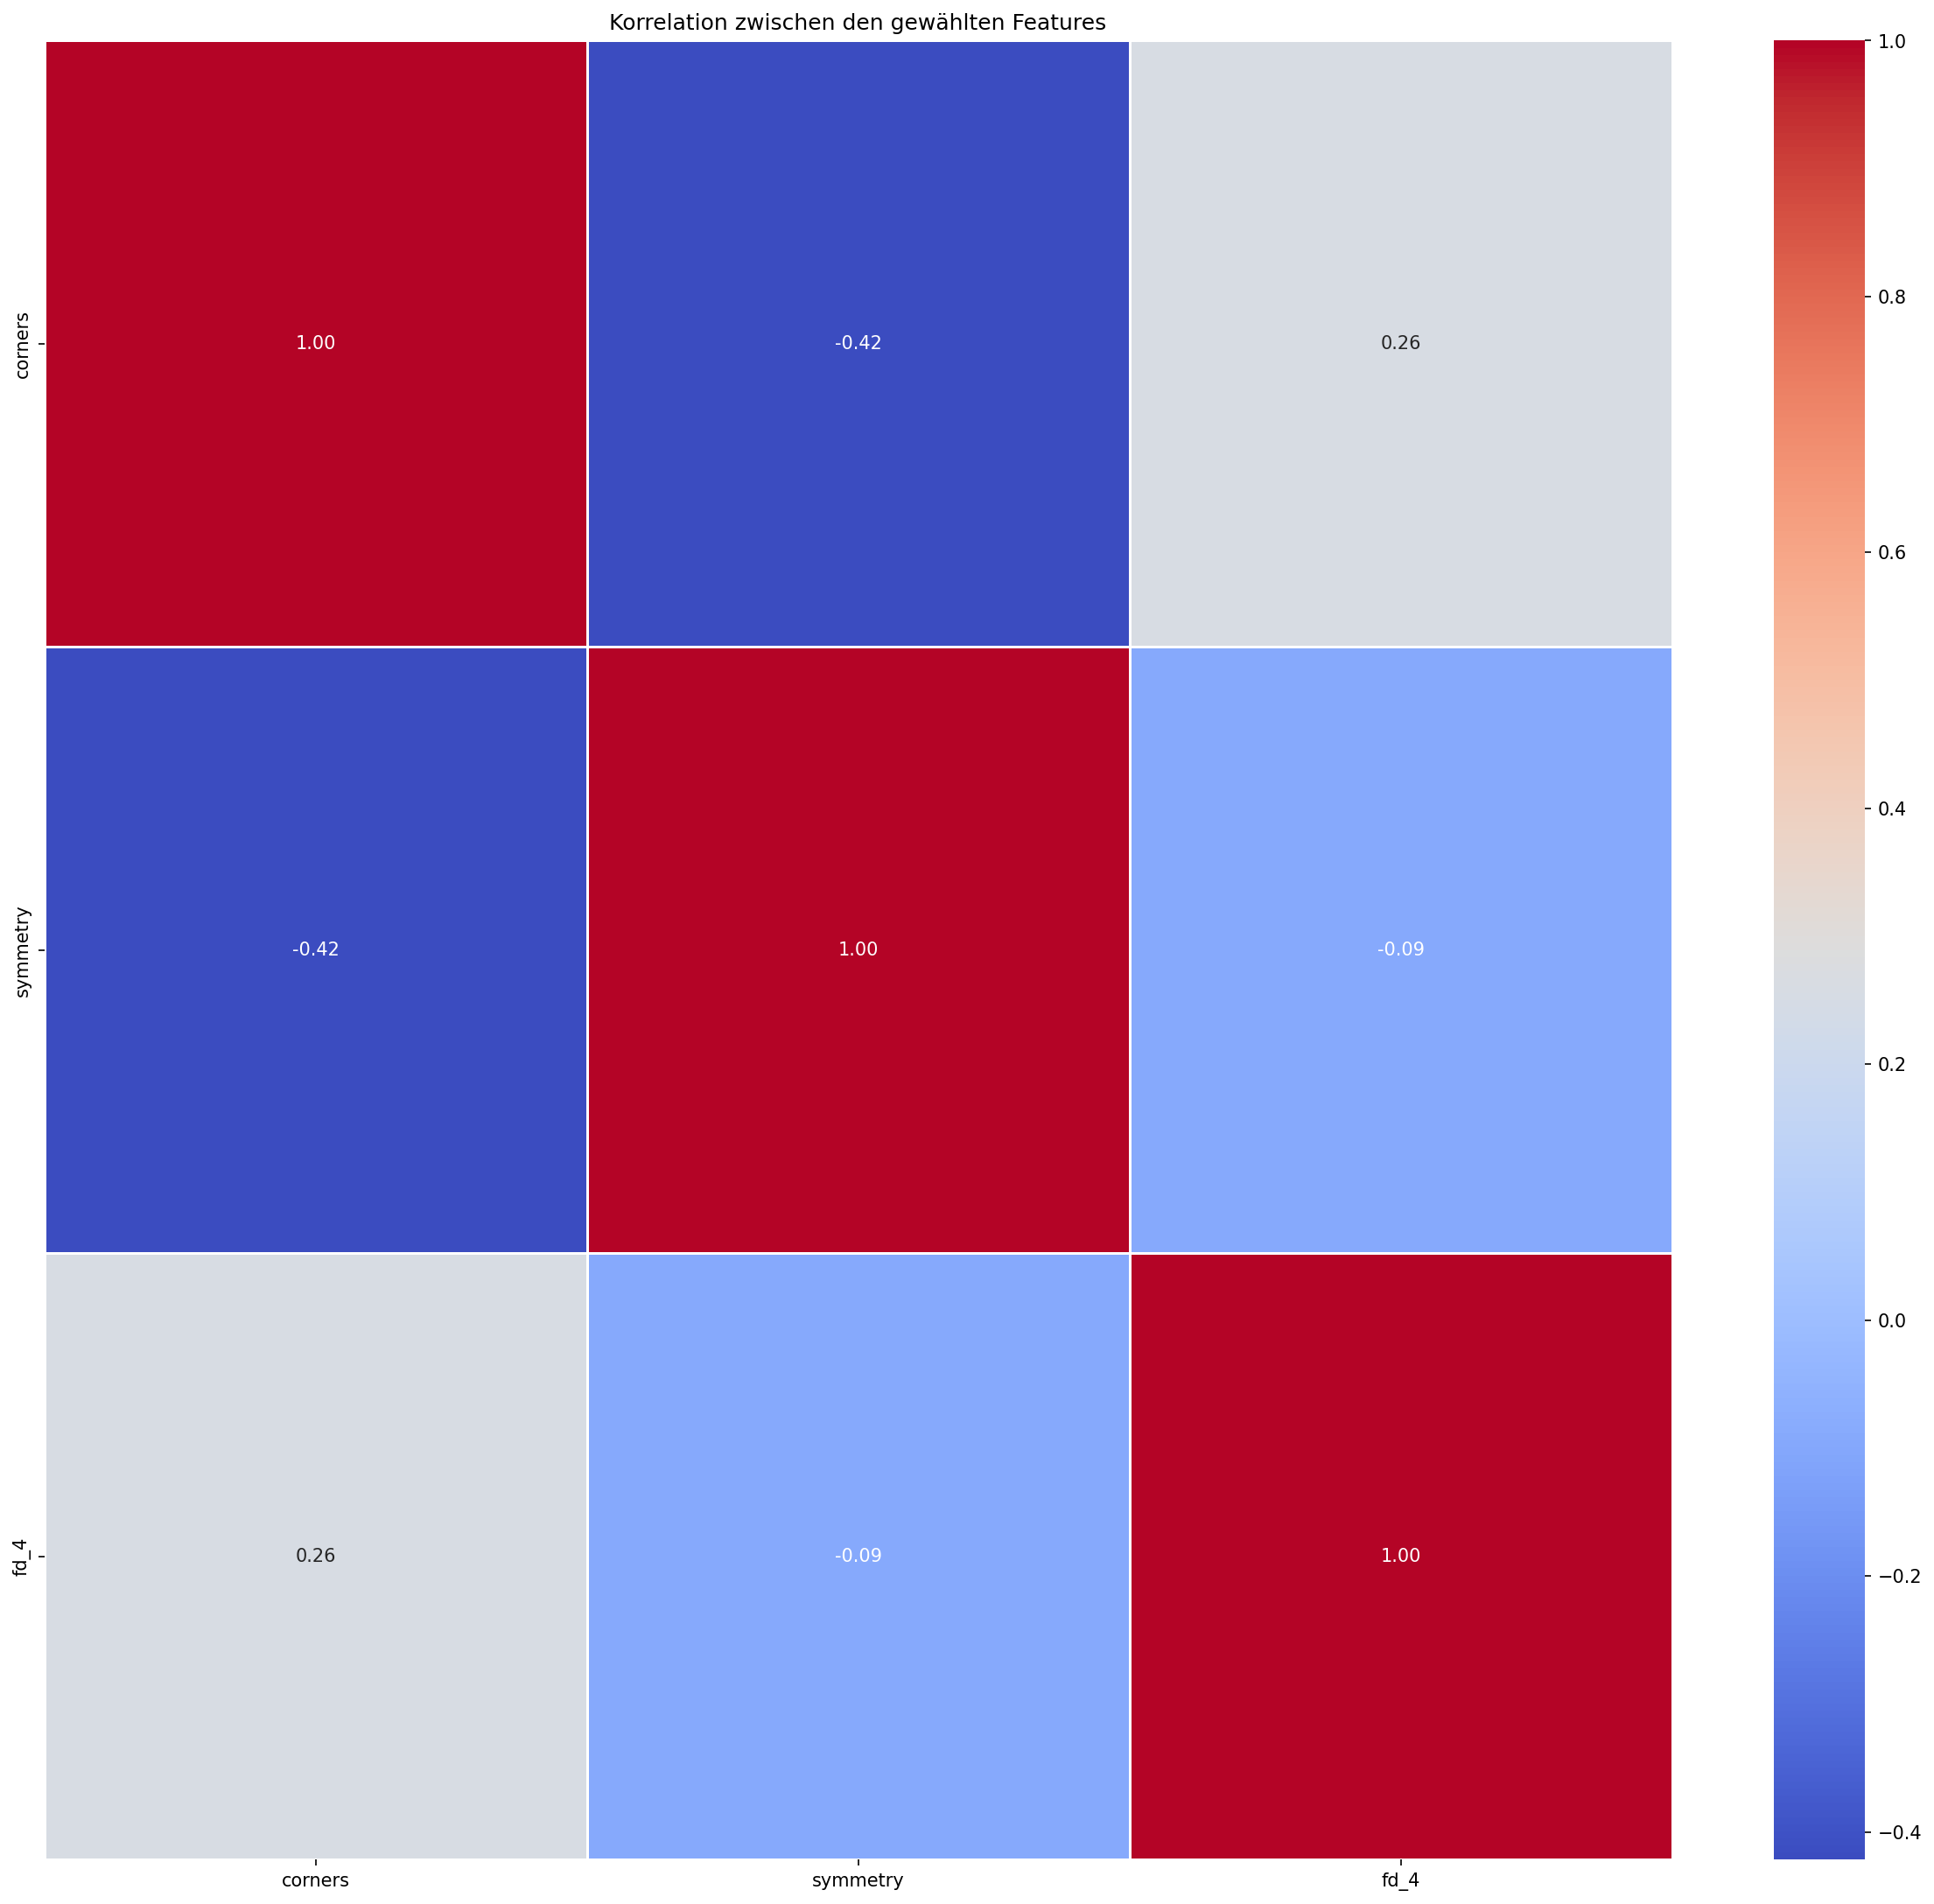

In [17]:
corr = df[selected_features].corr()

plt.figure(figsize=(20, 18))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Korrelation zwischen den gewählten Features")
plt.show()

Du weist das man die korrelationsmatrik mit den Obbjekten macht die zu klassiefizieren sind. 
Nicht mit den Merkmalen. soweit ich weiß.

aber die precision, recall, f1-score das schaut gur aus  

In [18]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
pred = model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

         cat       0.61      0.71      0.66       528
     unicorn       0.66      0.55      0.60       533

    accuracy                           0.63      1061
   macro avg       0.63      0.63      0.63      1061
weighted avg       0.63      0.63      0.63      1061



In [20]:
joblib.dump(model, "random_forest_model.pkl")
print("Model saved.")

Model saved.


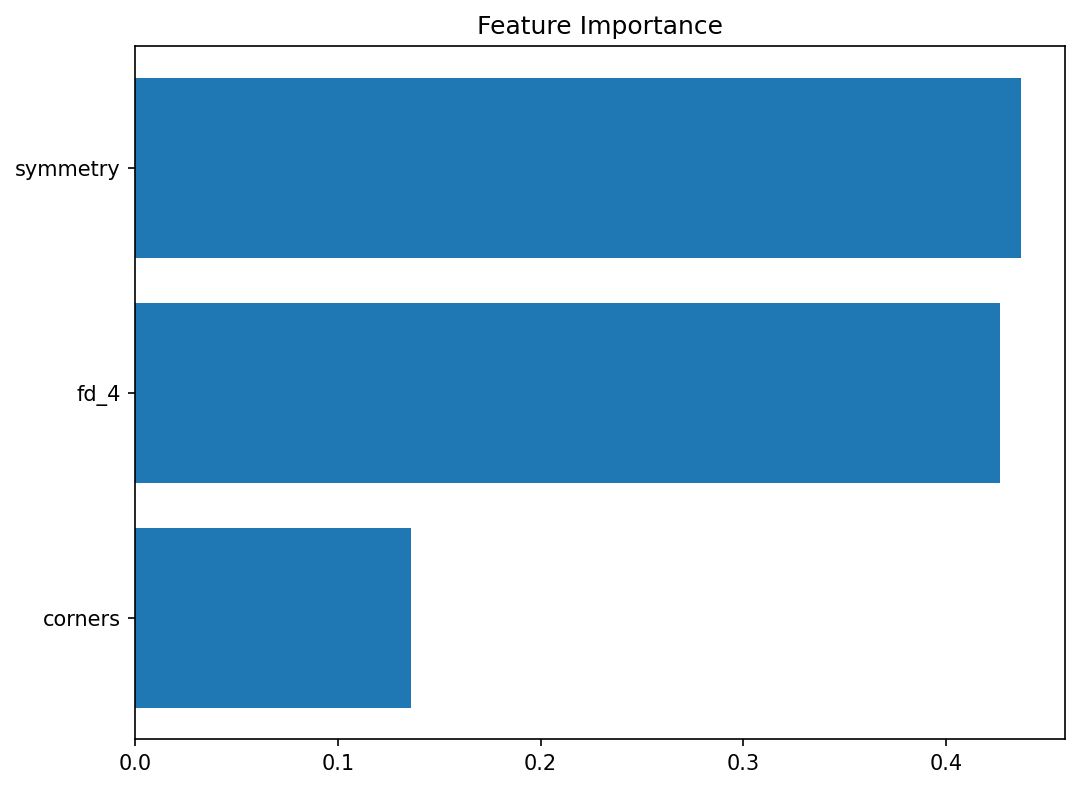

In [21]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
names = X.columns

idx = np.argsort(importances)

plt.figure(figsize=(8,6))
plt.barh(names[idx], importances[idx])
plt.title("Feature Importance")
plt.show()

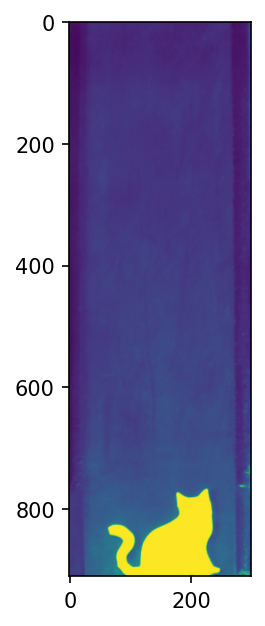

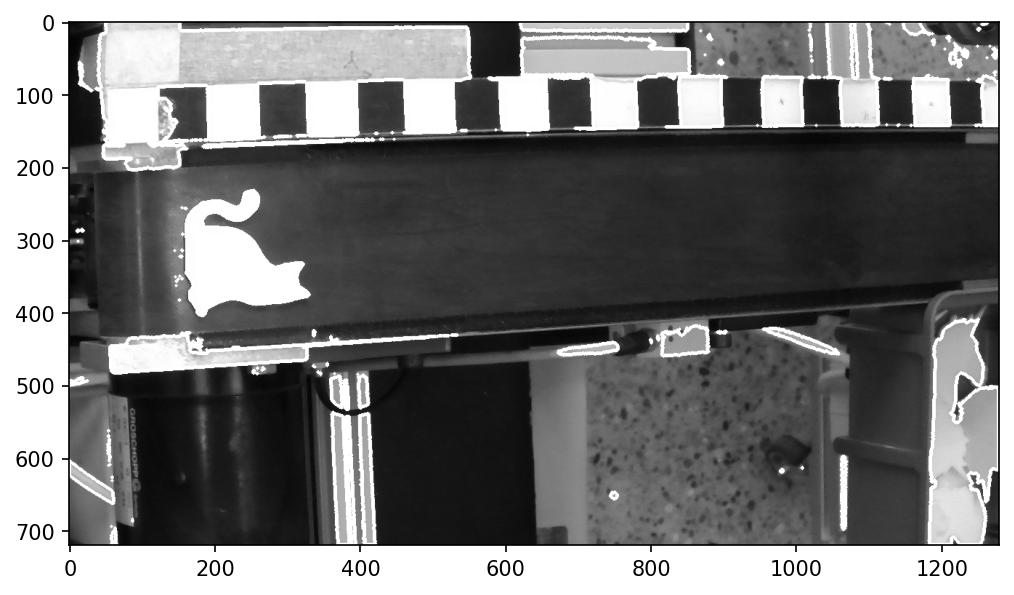

In [ ]:
test = cv.imread("obj/cat/foto_0.png")

test_rotated = cv.rotate(test, 2)

test_frame = cv.warpPerspective(test_rotated, M_for_all, (width, height))
plt.imshow(test_frame)


gray_image = cv.cvtColor(test, cv.COLOR_BGR2GRAY)


ret , img_thresh = cv.threshold(gray_image, 150, 255,cv.THRESH_BINARY)

uint8_img_thresh = img_thresh.astype(np.uint8)

contours , hierarchy = cv.findContours(uint8_img_thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)

img_with_contours = gray_image.copy()

cv.drawContours(img_with_contours, contours, contourIdx= -1 , color= (255, 255, 255),thickness=3)

plt.figure(figsize=(8, 6))
plt.imshow(img_with_contours, cmap='gray')